### Недообучение и переобучение

#### Цель работы

Познакомиться с основными проблемами обобщающей способности алгоритмов машинного обучения: overfitting (переобучение) и underfitting (недообучение).


#### Задания для выполнения

1. Загрузите первые 400 строк прилагающегося датасета `diabetes.csv`.
2. Сделайте количественное описание датасета: число признаков, статистику по признакам.
3. Отделите целевую переменную `Outcome`.
4. Разделите данные на обучающую и валидационную выборки при помощи `train_test_split` из библиотеки `sklearn.model_selection` в соотношении 80-20 (для этого укажите параметр test_size=0.2) с перемешиванием, указав значение параметра `random_state=42`.
5. Создайте объект `DecisionTreeClassifier(random_state=1)`. Обучите модель на обучающих (трейновых) данных. Сделайте предсказание на трейновом и валидационном наборе признаков. Выведите значения метрики `f1-score`для трейнового и валидационного наборов данных. По полученным значениям метрик сделайте предположение о переобученности модели.
6. Произведите кросс-валидацию с использованием функции `cross_validate` из библиотеки  `sklearn.model_selection`. По полученным данным, постройте график зависимости значений `f1-score` от набора данных соответствующей итерации. По графику убедитесь в том, что имеет место переобученность модели.
7. Для борьбы с переобучением регуляризуйте модель `DecisionTreeClassifier`, уменьшив глубину дерева, указав параметр регуляризации `max_depth=3`.
8. Снова проделайте пункт 6 с учётом регуляризации и убелитесь по графику в том, что модель больше не является переобученной.
9. Теперь рассмотрите проблему недообучения модели. Для борьбы с недообучением модели добавьте данные.
Для этого загрузите все строки датасета `diabetes.csv`.
10. Обучите модель `DecisionTreeClassifier(random_state=1, max_depth=3)` на всех данных и убедитесь в том, что значение метрики `f1-score` улучшилось.


#### Методические указания

Как всегда загружаем стандартный набор необходимых библиотек:


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

##### Диагностика моделей классификации

Для первого примера воспользуемся синтетическими данными. Сгенерируем большой и достаточно сложный датасет для классификации. В нем будет 10 тысяч точек и 500 атрибутов. Из них всего 50 признаков будут информативными. Сразу после генерации разделим получившийся датасет на обучающую и тестовую выборки:

In [171]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)

Обучим на этом наборе данных самую простую модель - логистическую регрессию. Выведем оценки точности этой модели на обучающей и тестовой выборке:

In [172]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


В данном случае мы используем метрику эффективности классификации по умолчанию. В зависимости от задания вы можете проводить анализ по любой интересующей вас метрике. Получаем такие оценки эффективности данной модели

То, насколько отличается обучающая и тестовая эффективность модели - основной индикатор пере- или недообучения. Мы явно видим, что тестовая эффективность полученной модели неидеальна. Определить, что является причиной снижения качества модели - ее излишняя или недостаточная вариативность - основная цель диагностики модели машинного обучения.

Но по одним этим показателям очень сложно понять, в какой из двух ситуаций мы находимся. Поэтому прибегнем к построению кривых обучения. Это даст нам больше информации о том, каков уровень сложности модели по отношению к данным. Воспользуемся готовой реализацией построения кривых обучения из библиотеки продвинутой визуализации для машинного обучения yellowbrick:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

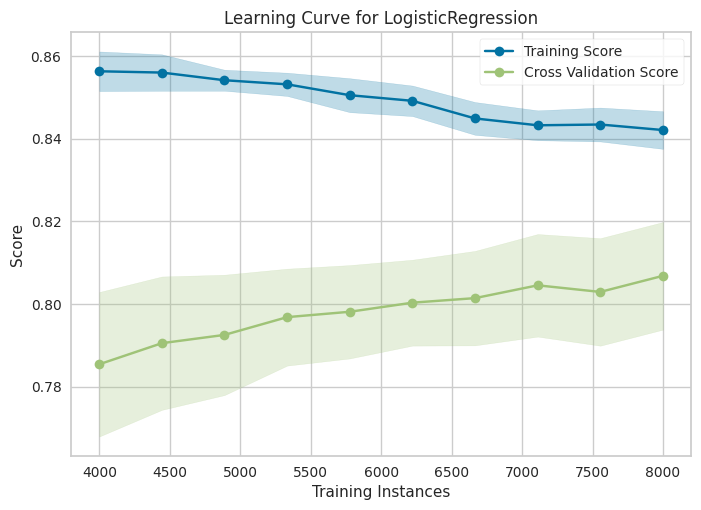

In [173]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show() 

Здесь мы задаем модель, которую хотим проверить и набор долей обучающей выборки, по которым будем ее обучать. В данном случае, эта функция построит модели логистической регрессии, обученные на 10%, 20%, и так далее до 100% обучающей выборки. А затем по каждой модели будет вычислена обучающая и тестовая эффективности. И эти показатели будут изображены на графике, то есть кривой обучения

Эта кривая показывает, что когда модель учится на небольшом объеме данных, она имеет прекрасную обучающую эффективность, но плохую тестовую. По мере увеличения объема обучающей выборки, эти эффективности сближаются, но между ними все еще сохраняется зазор.

Напомним, что большой промежуток между тестовой и обучающей эффективностью свидетельствует о переобучении. А низкое значение обучающей эффективности - о недообучении. Так что из этого присутствует в данной модели? Можно предположить, что модель немного переобучается. В пользу этого говорит и то, что наш исходный датасет очень разреженный (хотя мы об этом знаем только потому, что его сгенерировали). Более точно можно будет сказать сравнив эту модель с другими. Самый простой способ - использовать регуляризацию.

МЫ воспользуемся классификатором на основе гребневой регрессии. Вспомним, что обычный метод наименьших квадратов (воплощением которого является модель логистической регрессии) эквивалентна гребневой модели с параметром регуляризации, равном нулю. Чем больше этот параметр, тем больше регуляризации в модели и тем проще получаемые модели. Если мы предполагаем, что наша исходная модель переобучалась, то давайте построим и оценим модель с большим значением параметра регуляризации:

In [174]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


При таком огромном значении регуляризации мы почти гарантированно получим недообученную модель. Поэтому полезно будет сравнить результаты модели выше с этими. Вот что получилось у очень регуляризованной модели

Обратите внимание, что эффективность стала заметно ниже. Плюс, значения почти совпадают. То есть, почти никакой разницы не осталось. Это подтверждает наш первоначальный вывод о том, что в первой модели разница между обучающей и тестовой эффективностью получилась довольно большой для данной задачи. Построим кривые обучения для нашей второй модели:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

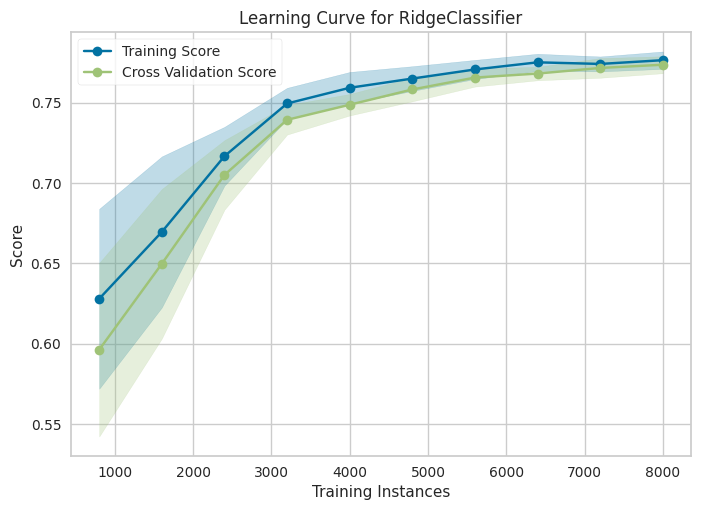

In [175]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

Получилась совсем другая картина

При анализе таких графиков надо обязательно обращать внимание на масштаб вертикальной оси. Несмотря на то, что кажется, будто значения в правой части графика (а нам интересны в первую очередь именно конечные значения эффективности, остальные - это просто предыстория) сильно больше, чем на первом, на самом деле они ниже. Данный график очень характерен для недообучения - низкие значения эффективности и практически никакой разницы между тестовой и обучающей эффективностью.

Если нерегуляризованная модель переобучается, а регуляризованная - недообучается, то где-то в промежутке есть оптимальная модель, котор

Для того, чтобы проанализировать данную задачу еще более глубоко построим график зависимости эффективности модели от значения параметра регуляризации. Для этого воспользуется логравномерным распределением:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

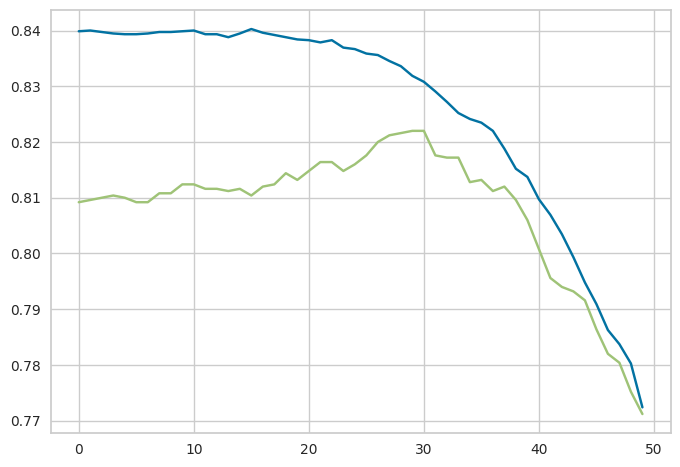

In [176]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(2, 6, 50):
  ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains)
plt.plot(tests)

Данный код построит 50 моделей, различающихся только параметром регуляризации. Он будет лежать в диапазоне от 100 ($10^2$) до 100 000 ($10^6$). Диапазон подбирается эмпирически, интересующий нас интервал значений параметров регуляризации будет разный в других задачах. Поэтому рекомендуется сначала построить модели в очень широких пределах (скажем, от -6 до 6), а затем сужать его настолько, чтобы на графике наглядно проявилась примерно такая картина

Здесь мы видим, что при определенных значениях параметра регуляризации тестовая эффективность модели (а нас в конечном итоге интересует именно она) лучше, чем во всех остальных. Подбором или алгоритмически можно найти такое оптимальное значение параметра регуляризации. Оно дает нам модель, которая имеет оптимальный уровень сложности для данного конкретного датасета. Давайте выведем получившиеся показатели:

In [177]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8311
Test score: 0.8228


Эта модель получилась немного лучше, чем самая первая, модель логистической регрессии

Это произошло потому, что мы за счет регуляризации убрали негативный эффект переобучения. Давайте построим кривые обучения, чтобы посмотреть, как они выглядят для "хорошей" модели

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

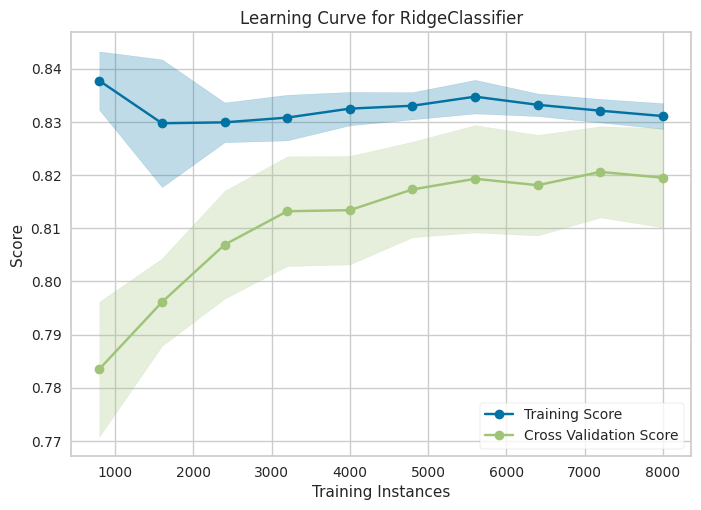

<Axes: title={'center': 'Learning Curve for RidgeClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [178]:
from yellowbrick.model_selection import LearningCurve
from sklearn.linear_model import RidgeClassifier
import numpy as np

visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), 
    train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y)

visualizer.show()

Опять же, с оглядкой на масштаб вертикальной оси мы видим, что и уровень эффективности выше, чем в первой модели и разница между двумя эффективностями тоже сократилась. И то и другое - это свидетельство большей обобщающей способности модели.

##### Диагностика моделей регрессии

Для более реалистичного примера загрузим датасет цен на недвижимость:

In [179]:
import pandas as pd
from sklearn.model_selection import train_test_split

names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('data/housing.data.txt', sep=r'\s+', names=names)
X = df.drop('MEDV', axis=1).values
y = df['MEDV'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Это набор данных для решения задачи регрессии - предсказания цен объектов недвижимости по их характеристикам. Самостоятельно изучите данный датасет, приведите его численные показатели. А мы сразу выведем оценку эффективности простой модели - линейной регрессии

Большой разрыв между обучающей и тестовой эффективностью также сразу должен навести на мысль о переобучении данной модели. Попробуем проверить наше предположение при помощи кривых обучения (обратите внимание, что мы сразу используем гребневую модель с очень маленькой регуляризацией):

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

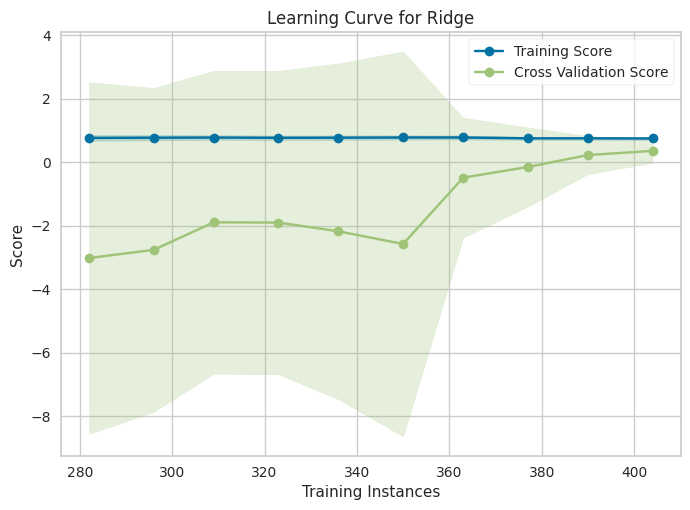

In [180]:
from sklearn.linear_model import Ridge
from yellowbrick.model_selection import LearningCurve
import numpy as np

visualizer = LearningCurve(
    Ridge(alpha=0.0001), scoring='r2', train_sizes=np.linspace(0.7, 1.0, 10)
).fit(X, y).show()

Может потребоваться несколько попыток, чтобы заставить график выглядеть показательно (может понадобится изменить масштаб по разным осям), но в итоге мы можем наблюдать примерно такой график

Обратите внимание, что промежуток между обучающей и тестовой эффективностью все равно очень большой в правой части графика, хоть чисто визуально и не выглядит таковым. Просто тестовая эффективность в левой части графика просто ужасна, и она сильно смещает вертикальную ось вниз. Тем не менее, можно обоснованно предположить, что такая модель переобучается на имеющихся данных.

Сразу построим график зависимости эффективности модели от значения параметра L2-регуляризации:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

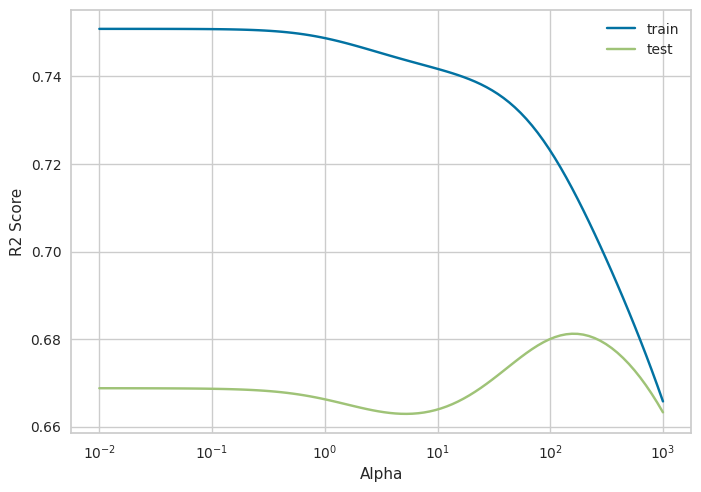

In [181]:
from sklearn.linear_model import Ridge
import numpy as np
import matplotlib.pyplot as plt

trains = []
tests = []
alphas = np.logspace(-2, 3, 100)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(alphas, trains, label="train")
plt.plot(alphas, tests, label="test")
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.legend()
plt.show()

На этом графике очень наглядно виден характер кривых регуляризации. В левой области лежат значения, которые дают слишком сложные модели. Они хорошо описывают обучающую выборку, но не обобщаются на тестовую. Это зона переобучения. В правой области - значения, порождающие слишком простые модели. Они одинаково плохо описывают и обучающую и тестовые выборки. Это зона недообучения. Посередине между ними лежит оптимальный уровень сложности модели для данного конкретного датасета. Здесь эта оптимальность очень хорошо выражена.

Численно можно подобрать оптимальное значение параметра регуляризации для гребневой регрессии. Давайте выведем эффективность такой оптимальной модели:

In [182]:
lr = Ridge(alpha=0.18).fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.75
Linear Regression-Test set score: 0.67


Можно видеть, что они значительно выше, чем у первой модели. Опять же, мы оптимизировали модель за счет борьбы с ее переобучением. Давайте построим кривую обучения данной модели:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

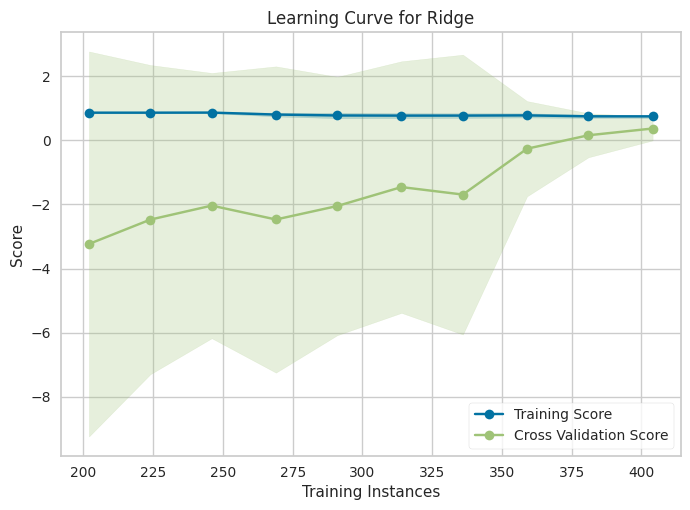

In [183]:
visualizer = LearningCurve(
    Ridge(alpha=0.18), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show() 

Опять же, вся разница между кривыми обучения лежит в масштабе вертикальной оси. По сравнению с предыдущим графиком этот выглядит гораздо более адекватно.

Здесь можно заметить, что несмотря на то, что мы подобрали наилучший уровень сложности модели, ее эффективность все равно не идеальна. Присутствует и разница между тестовой и обучающей эффективностью. Это свидетельствует о том, что и в нашей самой лучшей модели все равно имеется и bias и variance в какой-то степени. И хоть мы нашли лучшую модель, она лучшая из одного отдельного класса моделей - гребневой регрессии.

Поэтому можно исследовать на этом же датасете и другие модели. Так, например, можно попробовать другой вид регуляризации - лассо. В библиотеке sklearn эта модель работает только как регрессор, то есть она не подходит для задач классификации. Поэтому мы не могли использовать ее в предыдущем примере. Сразу построим кривые регуляризации:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

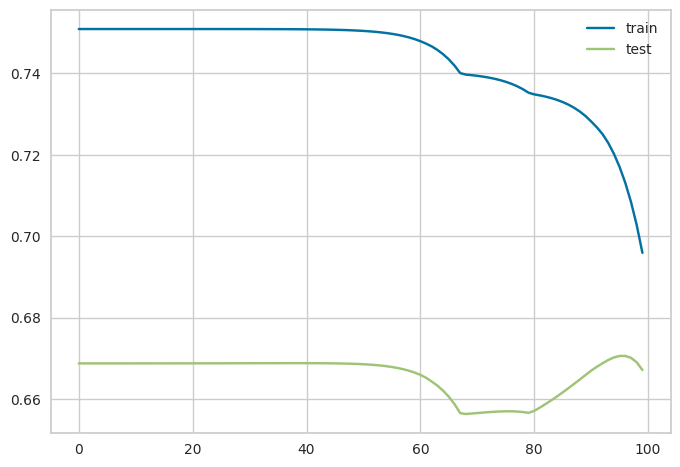

In [184]:
from sklearn.linear_model import Lasso
trains = []
tests = []
for i in np.logspace(-4, 0, 100):
  ridge = Lasso(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

Получается такой график тоже с отчетливыми зонами пере- и недообучения

Точно также можно исследовать и другие виды моделей. Итого для диагностики моделей используется три инструмента:

- сравнение обучающей и тестовой эффективности
- анализ формы кривых обучения
- построение кривых по одному из гиперпараметров модели, который влияет на соотношение bias/variance

Но главное - это сравнение между собой нескольких моделей одного типа, но с разным уровнем сложности (еще говорят про модели с разной склонностью к пере- или недообучению).

##### Диагностика на реальных данных

В реальных задачах диагностика моделей машинного обучения может быть не настолько очевидной. Зачастую используются модели, которые не используют регуляризацию в явном виде. В этом примере рассмотрим приемы диагностики моделей на реальных данных. Будем использовать известный датасет для классификации "Диабет"

Загружаем данные:

In [185]:
import pandas as pd
df = pd.read_csv('data/diabetes.csv',nrows=400)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Обратите внимание, что мы считали только первые 200 строк из файла. Этим мы имитируем обучение на части данных. Формируем обучающую и тестовую выборки:

In [186]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Для моделирования выберем совершенно другой тип модели - решающие деревья. Создадим объект модели дерева решений и исследуем его эффективность:

In [187]:
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))
print("Train f1_score = %.4f" % f1_score(y_train, y_train_pred))
print("Test f1_score = %.4f" % f1_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7000
Train f1_score = 1.0000
Test f1_score = 0.6364


Даже без построения кривых обучения здесь очевидно переобучение модели. Но все же для тренировки распознавания разных ситуаций на графике построим кривую обучения:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

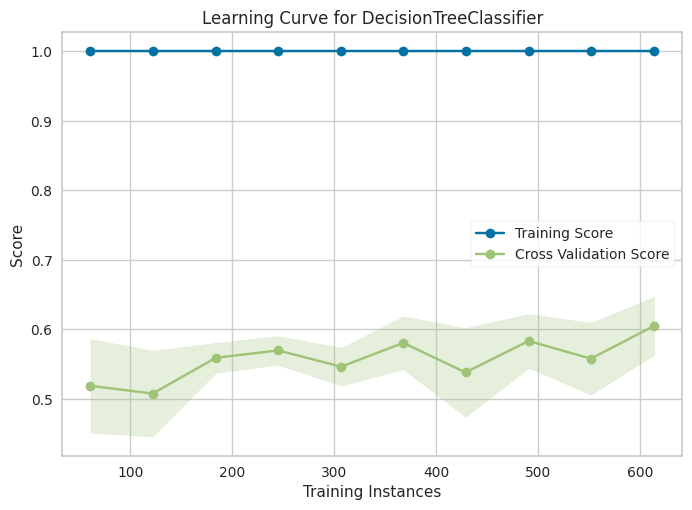

<Axes: title={'center': 'Learning Curve for DecisionTreeClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [188]:
from yellowbrick.model_selection import LearningCurve
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('data/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)

# Разделяем на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Кривая обучения
visualizer = LearningCurve(
    DecisionTreeClassifier(random_state=1), 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1',
    cv=5
)

visualizer.fit(X, y)
visualizer.show()

У деревьев решений один из параметров - максимальная глубина дерева как раз и влияет на склонность модели к переобучению. Аналогом регуляризации для деревьев будет искусственное ограничение максимальной глубины дерева. Давайте построим кривую обучения для такого регуляризованного дерева:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

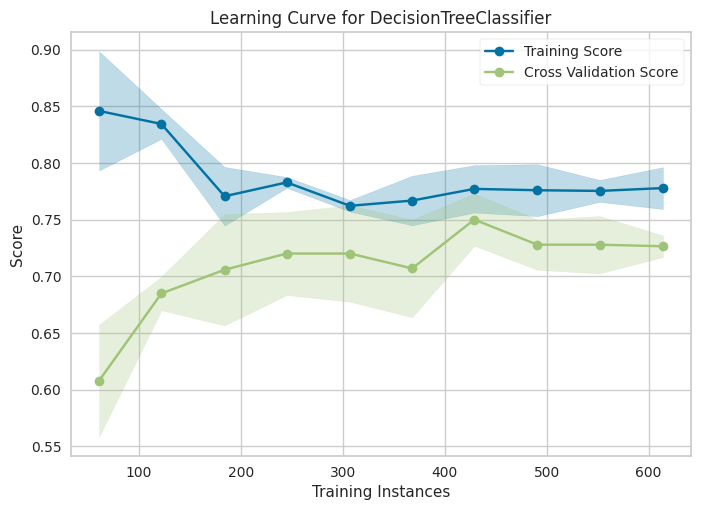

In [189]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=3), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show() 

Получается гораздо более качественная картина

Выведя метрики эффективности получаем более высокое качество модели на тестовых данных:

In [190]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('data/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Train f1_score = {f1_score(y_train, y_train_pred):.4f}")
print(f"Test f1_score = {f1_score(y_test, y_test_pred):.4f}")

Train f1_score = 1.0000
Test f1_score = 0.6379


Введение регуляризации, искусственное упрощение моделей - не единственный способ борьбы с переобучением. Самый лучший способ - это обучение на более полном датасете, то есть добавление большого количества данных. В этом примере мы специально не использовали весь имеющийся набор данных. На части модель сильно переобучается, но чем больше данных, тем меньше модели (даже одинаковые по сложности) становятся склонными к переобучению.

Для иллюстрации этого повторим обучение нерегуляризованного дерева решений на всем датасете:

In [191]:
from sklearn.metrics import accuracy_score
df = pd.read_csv('data/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))
print("Train f1_score = %.4f" % f1_score(y_train, y_train_pred))
print("Test f1_score = %.4f" % f1_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7273
Train f1_score = 1.0000
Test f1_score = 0.6379


Получившаяся модель значительно лучше, чем даже регуляризованное дерево. В общем случае, добавление данных работает лучше, чем регуляризация.

##### Диагностика недообучения

До сих пор мы рассматривали примеры, в которых модели по умолчанию демонстрируют явное переобучение. Но на практике чаще сталкиваются с недообучением, так как начинают анализ с более простых моделей, которые как раз склонны именно к недообучению. Рассмотрим в качестве примера более сложный датасет.

В sklearn есть встроенный механизм загрузки датасетов из онлайн репозитория OpenML. Возьмем оттуда датасет, посвященный проблеме управления истребителем F16:

In [192]:
from scipy.io import arff
import pandas as pd

data = arff.loadarff('data/delta_ailerons.arff')
df = pd.DataFrame(data[0])

# Декодируем байтовые строки в целевой переменной
df['binaryClass'] = df['binaryClass'].str.decode('utf-8')

# Разделяем на признаки и целевую
X = df.drop(columns=['binaryClass'])
y = df['binaryClass']

X.shape  

(7129, 5)

Он состоит из более 7 тысяч строк

Сформируем обучающую и тестовую выборки:

In [193]:
X = pd.get_dummies(X)
y = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Создадим и оценим простую модель логистической регрессии:

In [194]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


Построим кривую обучения данной модели:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

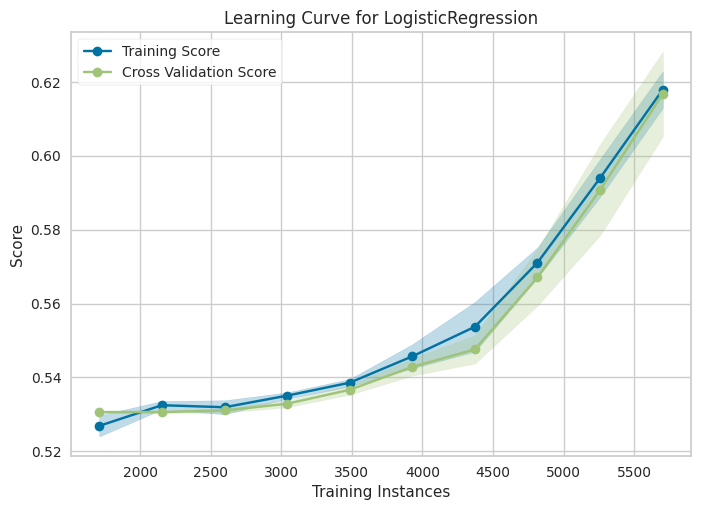

In [195]:
visualizer = LearningCurve(
    LogisticRegression(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show() 

Здесь очевидны признаки недообучения: низкий уровень обучающей эффективности, малый разрыв между обучающей и тестовой эффективностью. При недообучении регуляризация не поможет, даже навредит, так как еще усилит его. Поэтому единственный путь в этом случае - использовать более сложные, вариативные модели. Можно, например, попробовать многослойный перцептрон:

In [196]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier().fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9390


/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Самого главного мы добились - эффективность модели сильно выросла. Но давайте построим график обучения:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

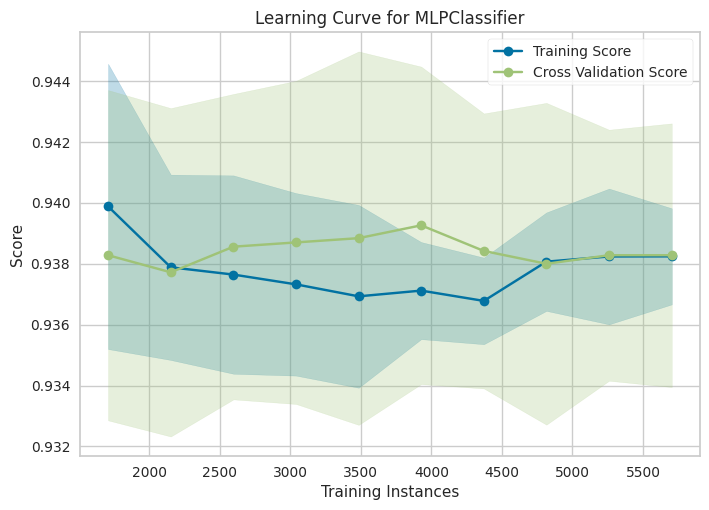

<Axes: title={'center': 'Learning Curve for MLPClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [197]:
from yellowbrick.model_selection import LearningCurve
from sklearn.neural_network import MLPClassifier

visualizer = LearningCurve(
    MLPClassifier(max_iter=1000, random_state=0), 
    scoring='accuracy', 
    train_sizes=np.linspace(0.3, 1.0, 10)
)
visualizer.fit(X, y)
visualizer.show()

Кроме использования более вариативных моделей самих по себе можно ввести в модель полиномиальные признаки:

In [198]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import PolynomialFeatures
model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(2).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(2).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9362


Полиномиальные модели являются естественным усложнением линейных и поэтому в случае недообучения исходной модели почти всегда обеспечивают увеличение эффективности модели

Для этой полиномиальной модели уже можно пробовать использовать регуляризацию и строить соответствующие кривые:

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

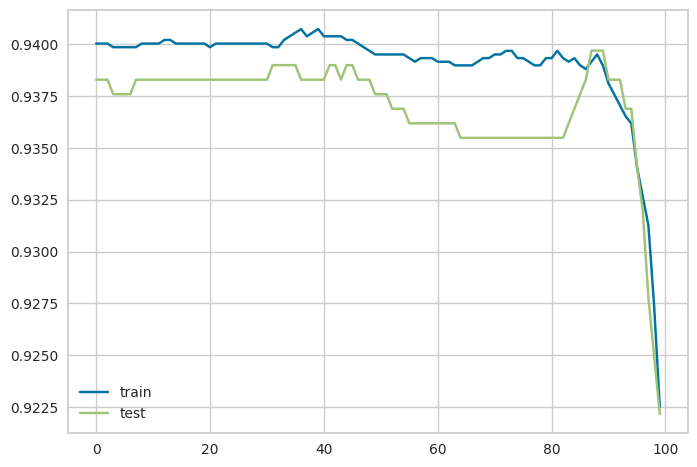

In [199]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(-7, 0, 100):
  ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
  trains.append(ridge.score(PolynomialFeatures(2).fit_transform(X_train), y_train))
  tests.append(ridge.score(PolynomialFeatures(2).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

В этом примере (как и во многих других реальных случаях) кривая регуляризации уже не такая очевидная и легко читаемая. Но и на ней можно при желании разглядеть область недообучения справа. Область переобучения здесь просматривается не так четко, так как тестовая эффективность практически не падает с уменьшением параметра регуляризации

Также можно заметить, что этот график уже не такой гладкий и ровный, как в предыдущих примерах. На нем присутствуют скачки, неравномерности. Это все случайные отклонения, которые обусловлены и артефактами в самих данных, и стохастичностью процесса обучения сложных моделей и случайными ошибками выборки, возникшими при разделении датасета на тестовую и обучающую выборки.

### Контрольные вопросы

**1. Что такое обобщающая способность модели?**

Обобщающая способность — это способность модели правильно предсказывать целевую переменную на **новых, не участвовавших в обучении данных**. Хорошая модель не просто запоминает обучающую выборку (что ведёт к переобучению), а выделяет общие закономерности. Она должна показывать стабильно высокое качество как на обучающих, так и на тестовых данных.

**2. Что такое переобучение модели?**

Переобучение (overfitting) — это явление, при котором модель слишком точно подстраивается под обучающую выборку, запоминая в том числе её шумы и случайные выбросы.

**Признаки переобучения:**
*   Очень высокая (часто идеальная) эффективность на обучающих данных.
*   Значительно более низкая эффективность на валидационных/тестовых данных (большой разрыв в метриках).
*   Модель «не видит» общую картину и не способна обобщить свои знания на новые примеры.

**Пример из работы:** `DecisionTreeClassifier` без ограничения глубины показал `Train score = 1.0000` и `Test score = 0.7273` — классический случай переобучения.

**3. Какие есть способы борьбы с переобучением?**

Основные способы:

1.  **Упрощение модели:**
    *   Ограничение сложности (например, `max_depth` для деревьев, уменьшение степени полинома).
    *   Уменьшение количества признаков (отбор признаков).
2.  **Регуляризация:** добавление штрафа за сложность модели в функцию потерь (L1, L2).
3.  **Увеличение обучающей выборки:** больше данных позволяют модели лучше улавливать общие закономерности, а не шумы. (Продемонстрировано на примере с полным датасетом `diabetes.csv`).
4.  **Аугментация данных:** искусственное создание новых примеров из существующих.
5.  **Ранняя остановка обучения (early stopping):** прекращение обучения до того, как модель начнет переобучаться (актуально для нейросетей и градиентного бустинга).

**4. Что такое регуляризация модели, как она работает?**

Регуляризация — это метод, который предотвращает переобучение путем добавления штрафного члена к функции потерь. Этот штраф зависит от величины параметров (весов) модели.

**Как работает:** Алгоритм минимизирует новую функцию: `Loss = Loss_основная + λ * Штраф(веса)`. Главная идея — заставить модель выбирать не только точное, но и более «простое» решение с небольшими весами. Параметр `λ` (alpha) контролирует силу регуляризации: чем он больше, тем сильнее «штраф» за сложность.

**5. Чем отличаются разные методы регуляризации моделей?**

Основные методы — **L1-регуляризация (Lasso)** и **L2-регуляризация (Ridge)**. Их главное различие в типе штрафа:

*   **L2 (Ridge):** Штраф = сумма квадратов весов (L2-норма). Она стремится равномерно уменьшить все веса, но не обнуляет их. Хорошо работает, когда большинство признаков влияют на результат (нет сильной разреженности).
*   **L1 (Lasso):** Штраф = сумма абсолютных значений весов (L1-норма). Она может **обнулять веса** для наименее важных признаков, что делает модель разреженной (sparse) и автоматически выполняет отбор признаков. Это удобно, когда среди множества признаков только несколько действительно важны.
*   **ElasticNet:** Комбинация L1 и L2 штрафов, объединяющая их свойства (может отбирать признаки, как L1, и стабилизировать веса, как L2).

**6. Что такое недообучение модели?**

Недообучение (underfitting) — это ситуация, когда модель слишком проста и не способна уловить основные закономерности даже в обучающих данных.

**Признаки недообучения:**
*   Низкая эффективность на обучающей выборке.
*   Низкая эффективность на тестовой выборке, при этом разрыв между ними незначителен.
*   Модель имеет высокое смещение (bias).

**Пример из работы:** `RidgeClassifier` с огромной альфой (`alpha=1000000`) показал низкие метрики на обучающей выборке (`0.7724`), и они практически не отличаются от тестовых (`0.7712`) — признаки недообучения.

**7. Какие есть способы борьбы с недообучением?**

Способы повышения сложности модели:

1.  **Усложнение модели:** переход к более сложным алгоритмам (например, от линейной модели к дереву решений или нейронной сети). В работе замена логистической регрессии на `MLPClassifier` значительно повысила качество.
2.  **Увеличение числа признаков:** создание новых признаков (например, полиномиальных, что было сделано с `PolynomialFeatures`).
3.  **Ослабление регуляризации:** уменьшение параметра, контролирующего штраф за сложность (например, `alpha` в Ridge/Lasso).
4.  **Увеличение «ёмкости» модели:** для деревьев решений — увеличение `max_depth`, для KNN — уменьшение `k`, для нейросетей — добавление слоёв или нейронов.
5.  **Уменьшение шума в данных:** очистка данных от выбросов.